In [1]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from warpSPHCore import radiusSearchCompactHashMap, sphOperation_warp
from warpSPHCore.enumTypes import *

# from diffSPH.neighborhood import buildNeighborhood
# from diffSPH.operations import SPHOperation
# from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
# from diffSPH.operations import KernelCorrectionScheme
# from diffSPH.kernels import *
# from diffSPH.plotting import visualizeParticles
# from diffSPH.kernels import getSPHKernelv2

import matplotlib.pyplot as plt
from demo_util import *

from warpSPHCore.util import generateNeighborTestData
from warpSPHCore import *

Warp DeprecationWarning: warp.config.verbose is deprecated; use warp.config.log_level = warp.LOG_DEBUG instead.


Warp 1.15.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "CPU"
     "cuda:0"   : "NVIDIA GeForce RTX 3090" (24 GiB, sm_86, mempool enabled)
   Kernel cache:
     /home/veldora/.cache/warp/1.15.0


In [3]:
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 128
dim = 2
jitter = 0.1
numParticles = nx**dim

warpOnly = False
periodic = True

positions, supports, _, domain, dx = generateNeighborTestData(
        nx, targetNumNeighbors, dim, periodic, device
)

positions = positions + jitter * dx * (torch.rand_like(positions) - 0.5)
masses = torch.full((positions.shape[0],), dx ** dim, device=device, dtype=positions.dtype)
kinds = torch.zeros(positions.shape[0], device=device, dtype=torch.int32)

particles = ParticleState(
        positions=positions.contiguous(),
        supports=supports.contiguous(),
        masses=masses.contiguous(),
        densities=None,
        kinds=kinds,
)

adjacency = radiusSearchCompactHashMap(
        particles,
        domain,
        mode=SupportScheme.SuperSymmetric,
)

densities = warpOperation(
        particles,
        OperationProperties(
                kernel=KernelFunctions.Wendland2,
                operation=WarpOperation.Density,
                supportMode=SupportScheme.Gather,
                operationMode=OperationDirection.AllToAll,
        ),
        domain,
        adjacency=adjacency,
)
particles.densities = densities

# print(domain)

Module warpSPHCore.radiusSearch.wp_compactHash a87b46c load on device 'cuda:0' took 6.35 ms  (cached)
Module warpSPHCore.coreOperations.wp_density 34c1c0c load on device 'cuda:0' took 6.53 ms  (cached)


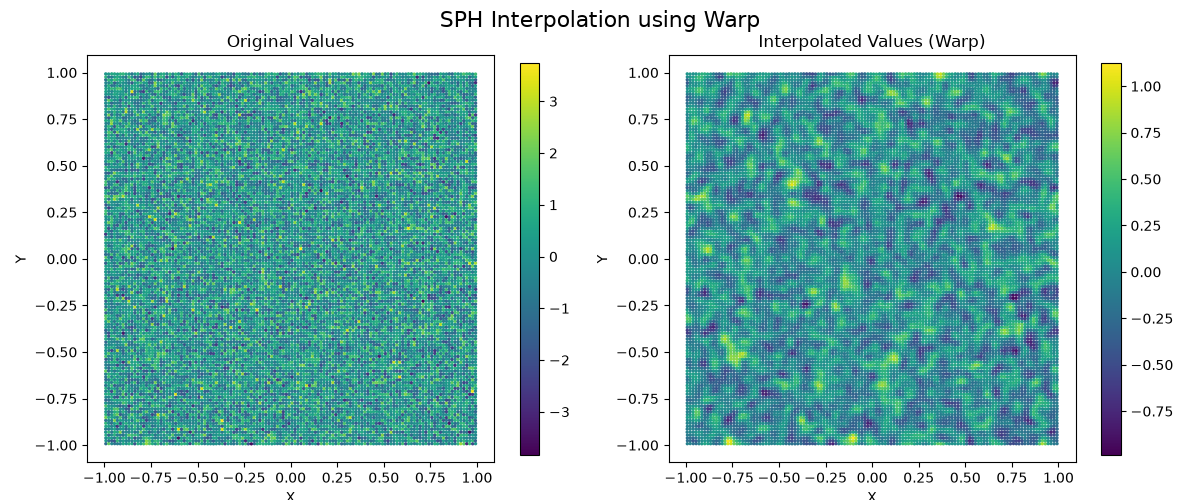

In [31]:
f = torch.randn(numParticles, device=device, dtype=torch.float32)

interpolated_warp = warpOperation(
    particles,
    queryValues = f,
    operationProperties = OperationProperties(
            kernel=KernelFunctions.Wendland2,
            operation=WarpOperation.Interpolate,
            supportMode=SupportScheme.Gather,
            operationMode=OperationDirection.AllToAll,
    ),
    domain = domain,
    adjacency=adjacency
)

markerSize = 2
fig, axis = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)
sc = axis[0, 0].scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=f.cpu(), cmap='viridis', s=markerSize)
axis[0, 0].set_title('Original Values')
fig.colorbar(sc, ax=axis[0, 0], shrink=0.95)
sc = axis[0, 1].scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=interpolated_warp.cpu(), cmap='viridis', s=markerSize)
axis[0, 1].set_title('Interpolated Values (Warp)')
fig.colorbar(sc, ax=axis[0, 1], shrink=0.95)

for ax in axis.flat:
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal')

fig.suptitle('SPH Interpolation using Warp', fontsize=16)

fig.tight_layout()

Scalar interpolation mean abs error: 0.005171285942196846


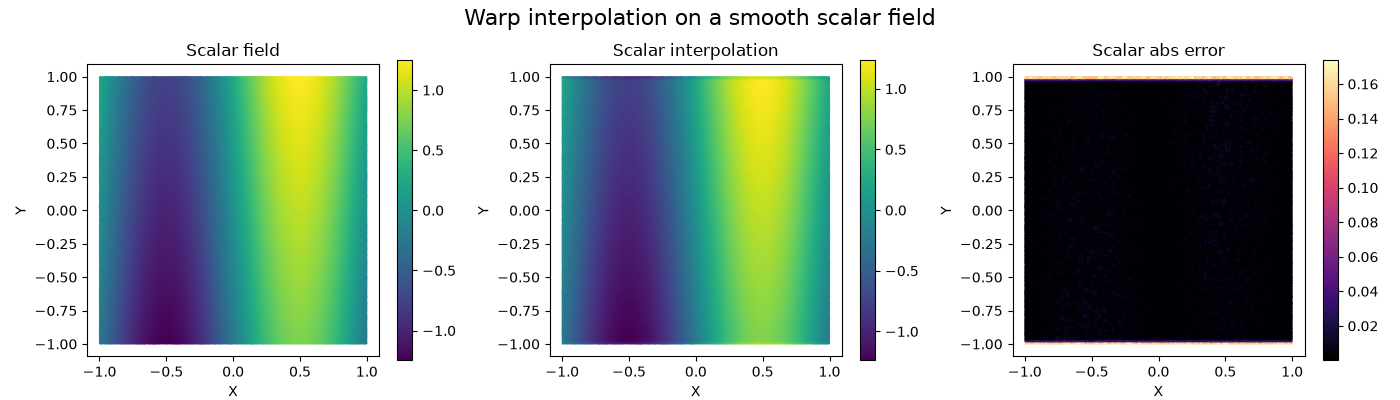

In [32]:
# -----------------------------------------------------------------------------
# Follow-up examples: keep the notebook Warp-only and runnable
# -----------------------------------------------------------------------------

# Scalar interpolation on a smooth field
scalar_field = torch.sin(positions[:, 0] * np.pi) + 0.25 * positions[:, 1]
scalar_interp = warpOperation(
    particles,
    queryValues=scalar_field,
    operationProperties=OperationProperties(
        kernel=KernelFunctions.Wendland2,
        operation=WarpOperation.Interpolate,
        supportMode=SupportScheme.Gather,
        operationMode=OperationDirection.AllToAll,
    ),
    domain=domain,
    adjacency=adjacency,
)

fig, axis = plt.subplots(1, 3, figsize=(14, 4), squeeze=False)
sc = axis[0, 0].scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=scalar_field.cpu(), cmap="viridis", s=2)
axis[0, 0].set_title("Scalar field")
fig.colorbar(sc, ax=axis[0, 0], shrink=0.95)
sc = axis[0, 1].scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=scalar_interp.cpu(), cmap="viridis", s=2)
axis[0, 1].set_title("Scalar interpolation")
fig.colorbar(sc, ax=axis[0, 1], shrink=0.95)
scalar_error = torch.abs(scalar_interp - scalar_field)
sc = axis[0, 2].scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=scalar_error.cpu(), cmap="magma", s=2)
axis[0, 2].set_title("Scalar abs error")
fig.colorbar(sc, ax=axis[0, 2], shrink=0.95)
for ax in axis.flat:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
fig.suptitle("Warp interpolation on a smooth scalar field", fontsize=16)
fig.tight_layout()
print("Scalar interpolation mean abs error:", scalar_error.mean().item())


Vector interpolation shape: (16384, 2)


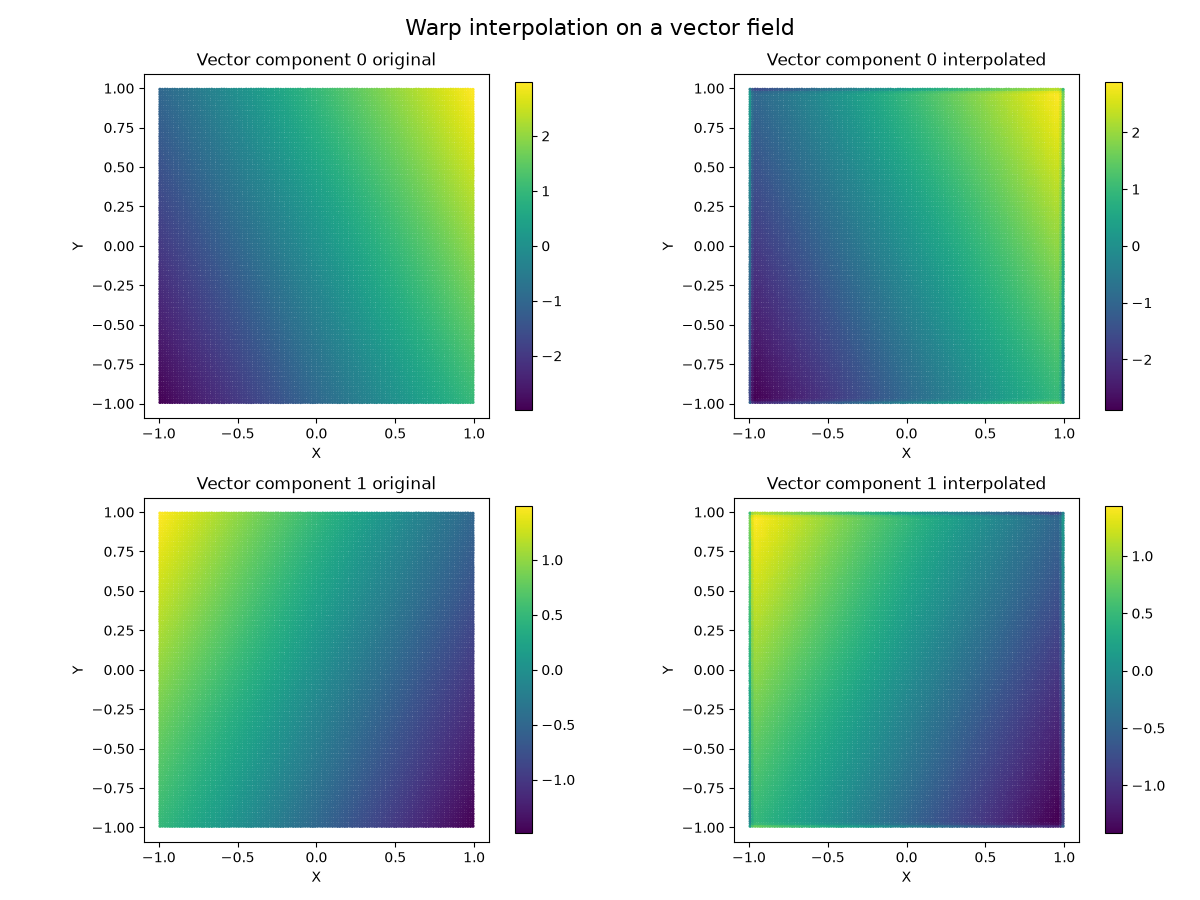

In [33]:
# Vector interpolation; plot each component separately to exercise rank-2 field handling.
vector_field = torch.stack(
    (
        2.0 * positions[:, 0] + positions[:, 1],
        -positions[:, 0] + 0.5 * positions[:, 1],
    ),
    dim=1,
)
vector_interp = warpOperation(
    particles,
    queryValues=vector_field,
    operationProperties=OperationProperties(
        kernel=KernelFunctions.Wendland2,
        operation=WarpOperation.Interpolate,
        supportMode=SupportScheme.Gather,
        operationMode=OperationDirection.AllToAll,
    ),
    domain=domain,
    adjacency=adjacency,
)

fig, axis = plt.subplots(2, 2, figsize=(12, 9), squeeze=False)
for row, component in enumerate((0, 1)):
    sc = axis[row, 0].scatter(
        positions[:, 0].cpu(),
        positions[:, 1].cpu(),
        c=vector_field[:, component].cpu(),
        cmap="viridis",
        s=2,
    )
    axis[row, 0].set_title(f"Vector component {component} original")
    fig.colorbar(sc, ax=axis[row, 0], shrink=0.95)
    sc = axis[row, 1].scatter(
        positions[:, 0].cpu(),
        positions[:, 1].cpu(),
        c=vector_interp[:, component].cpu(),
        cmap="viridis",
        s=2,
    )
    axis[row, 1].set_title(f"Vector component {component} interpolated")
    fig.colorbar(sc, ax=axis[row, 1], shrink=0.95)
    axis[row, 0].set_xlabel("X")
    axis[row, 0].set_ylabel("Y")
    axis[row, 1].set_xlabel("X")
    axis[row, 1].set_ylabel("Y")
    axis[row, 0].set_aspect("equal")
    axis[row, 1].set_aspect("equal")
fig.suptitle("Warp interpolation on a vector field", fontsize=16)
fig.tight_layout()
print("Vector interpolation shape:", tuple(vector_interp.shape))

Matrix interpolation shape: (16384, 2, 2)


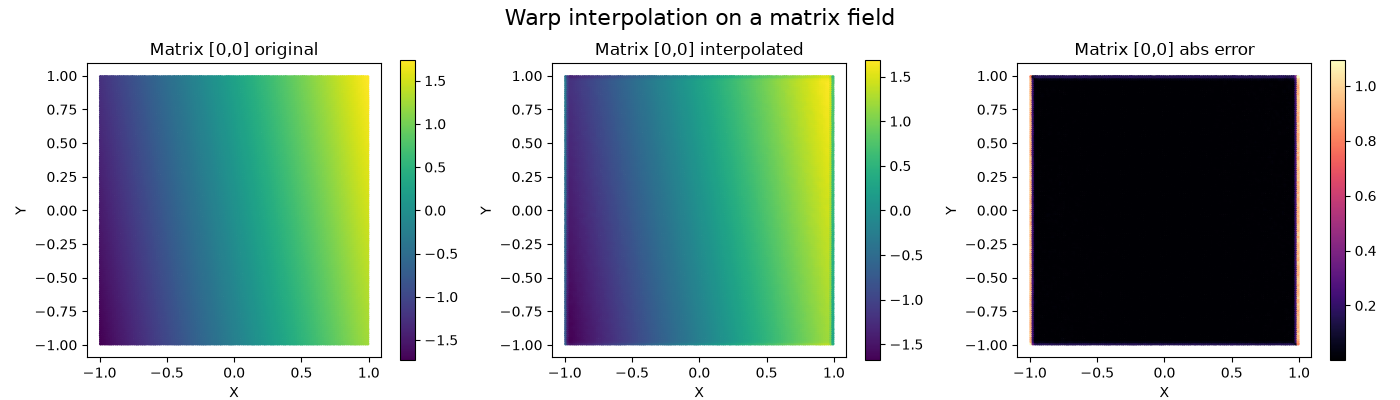

In [34]:
# Matrix interpolation; plot one representative component and verify the rank-3 output.
matrix_field = torch.empty((positions.shape[0], 2, 2), dtype=positions.dtype, device=positions.device)
matrix_field[:, 0, 0] = 1.5 * positions[:, 0] + 0.25 * positions[:, 1]
matrix_field[:, 0, 1] = -0.5 * positions[:, 0] + 0.75 * positions[:, 1]
matrix_field[:, 1, 0] = 0.2 * positions[:, 0] - 1.1 * positions[:, 1]
matrix_field[:, 1, 1] = -positions[:, 0] + 0.3 * positions[:, 1]
matrix_interp = warpOperation(
    particles,
    queryValues=matrix_field,
    operationProperties=OperationProperties(
        kernel=KernelFunctions.Wendland2,
        operation=WarpOperation.Interpolate,
        supportMode=SupportScheme.Gather,
        operationMode=OperationDirection.AllToAll,
    ),
    domain=domain,
    adjacency=adjacency,
)

fig, axis = plt.subplots(1, 3, figsize=(14, 4), squeeze=False)
component = matrix_field[:, 0, 0]
interp_component = matrix_interp[:, 0, 0]
sc = axis[0, 0].scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=component.cpu(), cmap="viridis", s=2)
axis[0, 0].set_title("Matrix [0,0] original")
fig.colorbar(sc, ax=axis[0, 0], shrink=0.95)
sc = axis[0, 1].scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=interp_component.cpu(), cmap="viridis", s=2)
axis[0, 1].set_title("Matrix [0,0] interpolated")
fig.colorbar(sc, ax=axis[0, 1], shrink=0.95)
component_error = torch.abs(interp_component - component)
sc = axis[0, 2].scatter(positions[:, 0].cpu(), positions[:, 1].cpu(), c=component_error.cpu(), cmap="magma", s=2)
axis[0, 2].set_title("Matrix [0,0] abs error")
fig.colorbar(sc, ax=axis[0, 2], shrink=0.95)
for ax in axis.flat:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
fig.suptitle("Warp interpolation on a matrix field", fontsize=16)
fig.tight_layout()
print("Matrix interpolation shape:", tuple(matrix_interp.shape))


Plain linear interpolation MAE: 0.03210444748401642
CRK linear interpolation MAE: 1.1851468570966972e-06


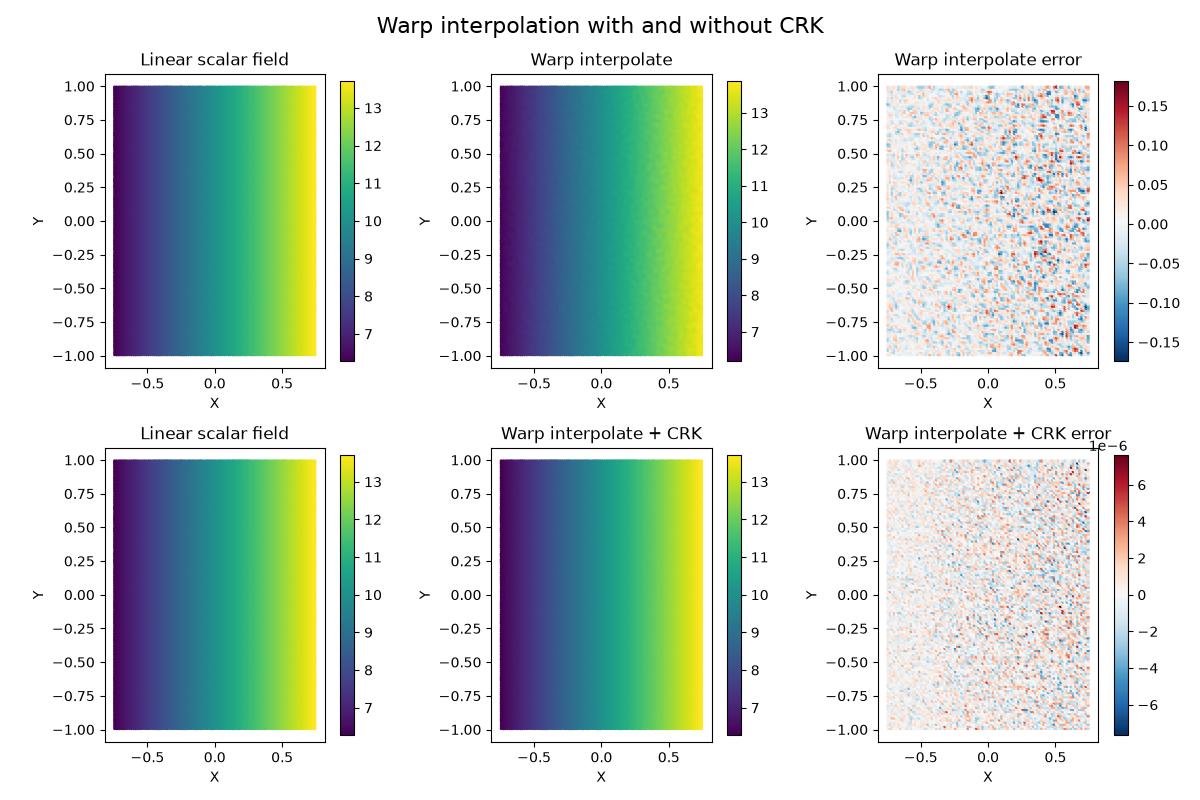

In [36]:
# CRK interpolation on a linear scalar field, with no diffSPH comparison.
linear_field = 5.0 * positions[:, 0] + 10.0
apparent_area, crk_density, crk_state = computeCRKFactors(
    queryParticles=particles,
    domain=domain,
    kernel=KernelFunctions.Wendland2,
    operationMode=OperationDirection.AllToAll,
    adjacency=adjacency,
)

plain_linear_interp = warpOperation(
    particles,
    queryValues=linear_field,
    operationProperties=OperationProperties(
        kernel=KernelFunctions.Wendland2,
        operation=WarpOperation.Interpolate,
        supportMode=SupportScheme.SuperSymmetric,
        operationMode=OperationDirection.AllToAll,
    ),
    domain=domain,
    adjacency=adjacency,
)
crk_linear_interp = warpOperation(
    particles,
    queryValues=linear_field,
    operationProperties=OperationProperties(
        kernel=KernelFunctions.Wendland2,
        operation=WarpOperation.Interpolate,
        supportMode=SupportScheme.SuperSymmetric,
        operationMode=OperationDirection.AllToAll,
    ),
    domain=domain,
    adjacency=adjacency,
    crkState=crk_state,
    queryVolumes=apparent_area,
    referenceVolumes=apparent_area,
)

mask = torch.logical_and(particles.positions[:,0] > -0.75, particles.positions[:,0] < 0.75) # The field has a step at the boundary so mask this out so it doesnt affect the error metrics
# Note the correct masking would be -1 + 2 * h

fig, axis = plt.subplots(2, 3, figsize=(12, 8), squeeze=False)
sc = axis[0, 0].scatter(positions[mask, 0].cpu(), positions[mask, 1].cpu(), c=linear_field[mask].cpu(), cmap="viridis", s=2)
axis[0, 0].set_title("Linear scalar field")
fig.colorbar(sc, ax=axis[0, 0], shrink=0.95)
sc = axis[1, 0].scatter(positions[mask, 0].cpu(), positions[mask, 1].cpu(), c=linear_field[mask].cpu(), cmap="viridis", s=2)
axis[1, 0].set_title("Linear scalar field")
fig.colorbar(sc, ax=axis[1, 0], shrink=0.95)


sc = axis[0, 1].scatter(positions[mask, 0].cpu(), positions[mask, 1].cpu(), c=plain_linear_interp[mask].cpu(), cmap="viridis", s=2)
axis[0, 1].set_title("Warp interpolate")
fig.colorbar(sc, ax=axis[0, 1], shrink=0.95)
sc = axis[0, 2].scatter(positions[mask, 0].cpu(), positions[mask, 1].cpu(), c=(plain_linear_interp - linear_field)[mask].cpu(), cmap="RdBu_r", s=2)
axis[0, 2].set_title("Warp interpolate error")
fig.colorbar(sc, ax=axis[0, 2], shrink=0.95)


sc = axis[1, 1].scatter(positions[mask, 0].cpu(), positions[mask, 1].cpu(), c=crk_linear_interp[mask].cpu(), cmap="viridis", s=2)
axis[1, 1].set_title("Warp interpolate + CRK")
fig.colorbar(sc, ax=axis[1, 1], shrink=0.95)
sc = axis[1, 2].scatter(positions[mask, 0].cpu(), positions[mask, 1].cpu(), c=(crk_linear_interp - linear_field)[mask].cpu(), cmap="RdBu_r", s=2)
axis[1, 2].set_title("Warp interpolate + CRK error")
fig.colorbar(sc, ax=axis[1, 2], shrink=0.95)


for ax in axis.flat:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
fig.suptitle("Warp interpolation with and without CRK", fontsize=16)
fig.tight_layout()



print("Plain linear interpolation MAE:", torch.mean(torch.abs(plain_linear_interp - linear_field)[mask]).item())
print("CRK linear interpolation MAE:", torch.mean(torch.abs(crk_linear_interp - linear_field)[mask]).item())
